# [그림 6] MMF와 은행예금 잔액
# [그림 7] MMF와 은행예금 이자율
## required file
  - fred_api.py
  - plot_def.py
## required packages
```python
pip install datetime
```

In [1]:

import matplotlib.dates as mdates

# 폰트 설정
from plot_def import *
set_fonts()

## FRED 자료 불러오기

start='2021-01-01'
#end='2025-10-01'
end=date.today()

from fred_api import fetch_fred_series

## Fetch data from FRED
  - Deposits, All Commercial Banks (DPSACBM027NBOG)
  - Money Market Funds; Total Financial Assets, Level (MMMFFAQ027S)
      - Units: Millions of Dollars,Not Seasonally Adjusted
      - Frequency:Quarterly
  - Overnight Reverse Repurchase Agreements: Treasury Securities Sold by the Federal Reserve in the Temporary
Open Market Operations (RRPONTSYD)
  - National Rate: Savings (SNDR)
  - Treasury Yield: Money Market <100M (MMTY)
  - National Rate: Money Market <100M (MMNDR)

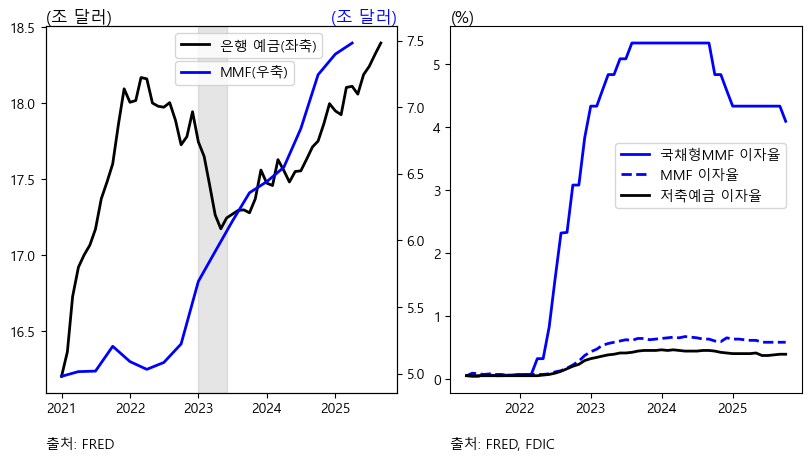

In [2]:
df0 = fetch_fred_series('DPSACBM027NBOG', start_date=start, end_date=end)

df1 = fetch_fred_series('MMMFFAQ027S', start_date=start, end_date=end)

df2 = fetch_fred_series('RRPONTSYD', start_date=start, end_date=end)

df3 = fetch_fred_series('SNDR', start_date=start, end_date=end)

df4 = fetch_fred_series('MMTY', start_date=start, end_date=end)

df5 = fetch_fred_series('MMNDR', start_date=start, end_date=end)

##왼쪽 그림
fig, ax = plt.subplots(1,2, figsize=(8, 4.5), constrained_layout=True)

ax_left = ax[0]
ax_right = ax_left.twinx()  # Create right-side y-axis

ax_left.plot(df0['observation_date'], df0['DPSACBM027NBOG']/1e3, label='은행 예금(좌축)', color='black', lw=2)
ax_right.plot(df1['observation_date'], df1['MMMFFAQ027S']/1e6, label='MMF(우축)', color='blue', lw=2)


ax[0].xaxis.set_major_locator(mdates.YearLocator())
ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

#라벨 위치 설정
ax_left.legend(loc='upper left',bbox_to_anchor=(0.35, 1.0))
ax_right.legend(loc='upper left',bbox_to_anchor=(0.35, 0.925))
ax_left.yaxis.label.set_visible(True)

#단위 표시
ax_left.text(0, 1.00, '(조 달러)', ha='left', va='bottom', color='black',
         fontsize=12, rotation=0, transform=ax[0].transAxes)
ax_right.text(1.0, 1.00, '(조 달러)', ha='right', va='bottom', color='blue',
         fontsize=12, rotation=0, transform=ax[0].transAxes)
#출처 표시
ax[0].text(0.0, -0.15, "출처: FRED", transform=ax[0].transAxes, fontsize=10, ha='left')
ax[0].grid(False)

# 음영 구간 추가
from datetime import datetime
shaded_periods = [
    (datetime(2023, 1, 1), datetime(2023, 6, 1))
    ]

for i in [0]:
    for start_date, end_date in shaded_periods:
        ax[i].axvspan(start_date, end_date, color='gray', alpha=0.2)


# 오른쪽 그림

ax[1].plot(df4['observation_date'], df4['MMTY'], label='국채형MMF 이자율', color='blue', lw=2)
ax[1].plot(df5['observation_date'], df5['MMNDR'], label='MMF 이자율', color='blue', lw=2, ls='--')
ax[1].plot(df3['observation_date'], df3['SNDR'], label='저축예금 이자율', color='black', lw=2)

# 라벨표시 위치
ax[1].legend(loc='upper left',bbox_to_anchor=(0.45, 0.7))

# X축 연도 표시 간격과 표시 형식
ax[1].xaxis.set_major_locator(mdates.YearLocator())
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 단위 표시 및 출처
ax[1].text(0, 1.00, '(%)', ha='left', va='bottom', color='black',
         fontsize=12, rotation=0, transform=ax[1].transAxes)

ax[1].text(0.0, -0.15, "출처: FRED, FDIC", transform=ax[1].transAxes, fontsize=10, ha='left')
ax[1].grid(False)


# 저장 및 출력
# python py 파일 이름과 동일한 이름으로 그림 파일을 tif, jpg로 저장하는 루틴

plot_save()